In [2]:
import warnings
warnings.filterwarnings("ignore")

In [4]:
import numpy as np
import pandas as pd
import copy 
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
!pip install scikit-learn


  Using cached joblib-1.5.2-py3-none-any.whl.metadata (5.6 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.1/11.1 MB 35.5 MB/s eta 0:00:00 0:00:01
Using cached joblib-1.5.2-py3-none-any.whl (308 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 30.3/30.3 MB 42.9 MB/s eta 0:00:00a 0:00:01
Using cached threadpoolctl-3.6.0-py3-none-any.whl (18 kB)


In [7]:
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler,OneHotEncoder
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay

##Generate Synthetic data with noise

In [12]:
X, y = make_moons(n_samples=800, noise=0.2, random_state=42)
X[0:3]

array([[ 1.4916376 , -0.12415845],
       [ 1.4007517 , -0.52063633],
       [ 0.85806768,  0.26889893]])

<function matplotlib.pyplot.show(close=None, block=None)>

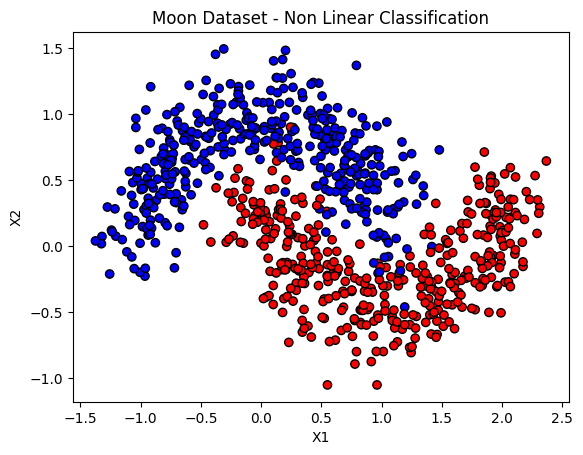

In [18]:
plt.scatter(X[:,0], X[:,1], c=y, cmap='bwr', edgecolors='k')
plt.title("Moon Dataset - Non Linear Classification")
plt.xlabel("X1")
plt.ylabel("X2")

plt.show

TASK : Make a Classifier using Multi Lpaer Perceptron to classify the datapoints correctly

Simple Multi Layer Perceptron 
1. 2 input features 
2. 2 neurons in hidden layer 
3. 2 outputs for binary classification 


Step 1 : Preparing data for Neural Network 

1. Split data into train and test split 
2. Scale data to zero mean and unit variance 

In [19]:
from sklearn.neural_network import MLPClassifier
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

For Neural Netwroks always scale the data.

In [21]:
scaler = StandardScaler()
X_train_std = scaler.fit_transform(X_train)
X_test_std = scaler.transform(X_test)

Step 2: Building the Neural Network.

Set Model Architecture

    Activation function to be used in hidden Neuron.

    Hidden Layer Size and Number of Neuron.

    Maximum number of iteration.

In [ ]:
mlp= MLPClassifier(hidden_layer_sizes=(2,), activation='relu', max_iter=200, random_state=42) #Identify linear value

Step 3: Train the model

In [23]:
#Train 
mlp.fit(X_train_std, y_train)

MLPClassifier(hidden_layer_sizes=(2,), random_state=42)

Step 4: Test Set Evaluation: Accuracy and Confusion Matrix

In [24]:
y_pred = mlp.predict(X_test_std)
print("Test Accuracy Score :" , accuracy_score(y_test, y_pred))

Test Accuracy Score : 0.8833333333333333


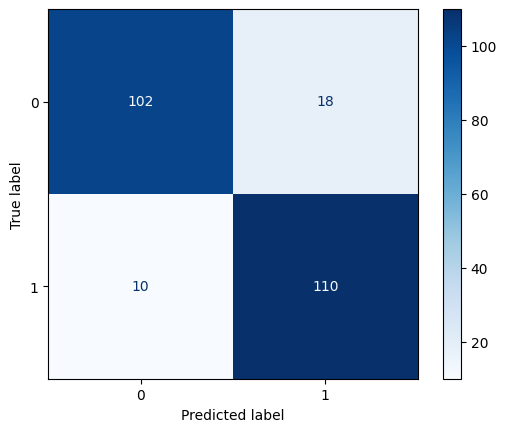

In [25]:
disp = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix(y_test, y_pred))
disp.plot(cmap=plt.cm.Blues)
plt.show()

Visualise the decion boundary

In [26]:
correct =  y_pred == y_test 
incorrect = ~correct

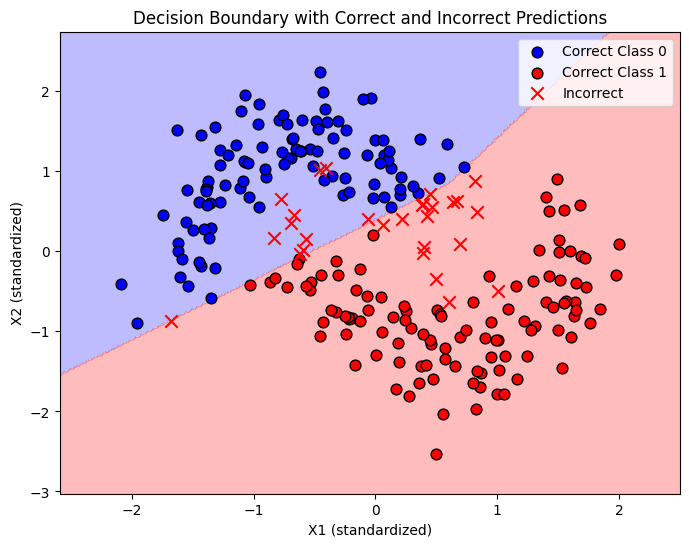

In [28]:
# Create a meshgrid for decision boundary
xx, yy = np.meshgrid(
    np.linspace(X_test_std[:, 0].min()-0.5, X_test_std[:, 0].max()+0.5, 300),
    np.linspace(X_test_std[:, 1].min()-0.5, X_test_std[:, 1].max()+0.5, 300)
)
grid = np.c_[xx.ravel(), yy.ravel()]
Z = mlp.predict(grid).reshape(xx.shape)

plt.figure(figsize=(8, 6))
plt.contourf(xx, yy, Z, alpha=0.3, cmap='bwr')

# Plot correct predictions for class 0 and class 1
plt.scatter(X_test_std[correct & (y_test == 0), 0], X_test_std[correct & (y_test == 0), 1],
            c='blue', label='Correct Class 0', edgecolor='k', marker='o', s=60)
plt.scatter(X_test_std[correct & (y_test == 1), 0], X_test_std[correct & (y_test == 1), 1],
            c='red', label='Correct Class 1', edgecolor='k', marker='o', s=60)

# Plot incorrect predictions as red 'x'
plt.scatter(X_test_std[incorrect, 0], X_test_std[incorrect, 1],
            c='red', label='Incorrect', edgecolor='k', marker='x', s=80)

plt.xlabel('X1 (standardized)')
plt.ylabel('X2 (standardized)')
plt.title('Decision Boundary with Correct and Incorrect Predictions')
plt.legend()
plt.show()

Classification with IRIS dataset.

TASK - To classify flowers into 1 of the 3 categories based on the available features. 

Features :
1. sepal length
2. sepal width 
3. petal length 
4. petal width

In [29]:
from sklearn.datasets import load_iris

In [30]:
#Load the iris dataset
iris = load_iris(as_frame=True)

In [31]:
data = pd.DataFrame(data=iris.data, columns=iris.feature_names)
data['species'] = iris.target
data.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [32]:
data.shape

(150, 5)

In [34]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   species            150 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 6.0 KB


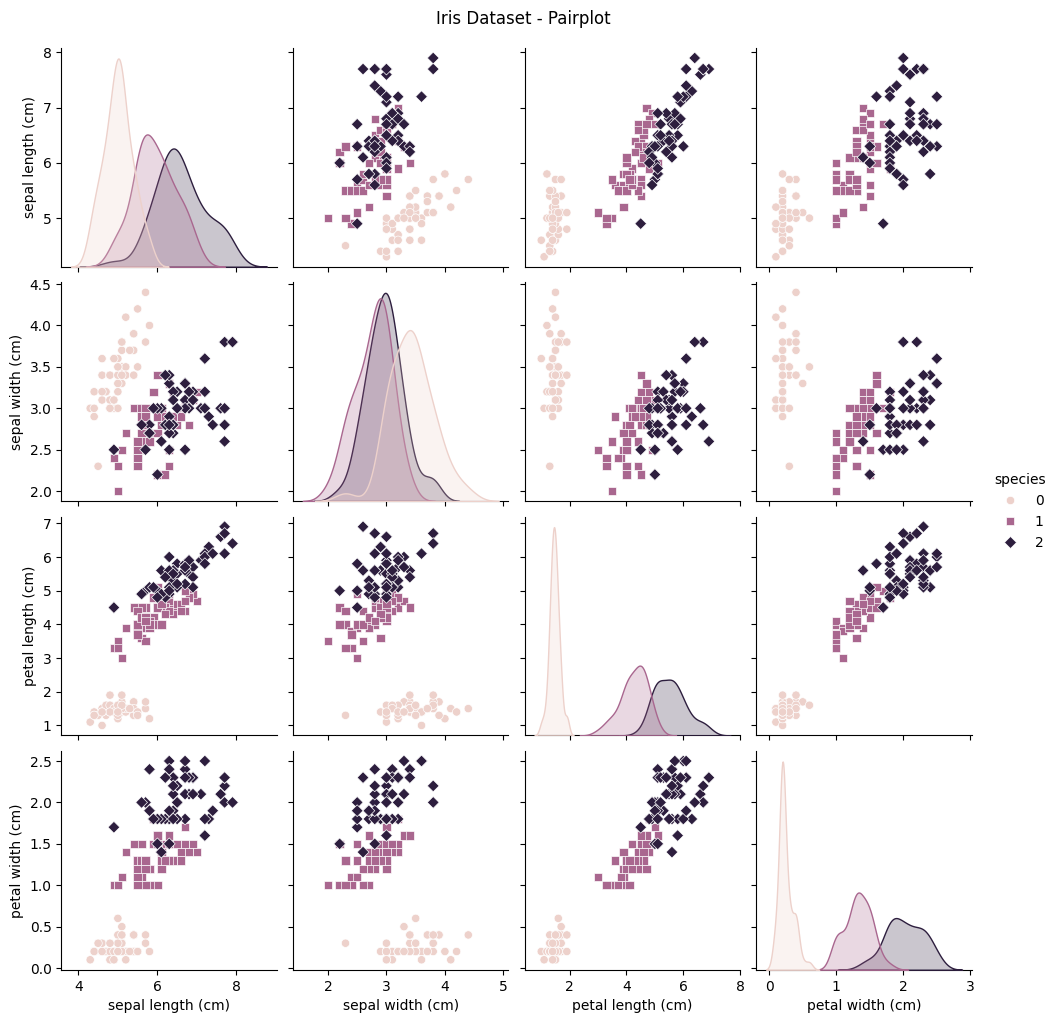

In [35]:
sns.pairplot(data, hue='species', markers=["o", "s", "D"])
plt.suptitle("Iris Dataset - Pairplot", y=1.02)
plt.show()

In [36]:
X, y = iris.data, iris.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

In [37]:
scaler = StandardScaler()
X_train_std = scaler.fit_transform(X_train)
X_test_std = scaler.transform(X_test)

MLP Classifier from sklearn
1. Output layer should have n-classes neuron.
2. Activation function - Softmax
3. Loss function used - Cross Entropy

Therefore, here we are using - 
1. Input layer = 4 neurons 
2. Hidden layer 
3. Output layer = 3 neurons 
4. Softmax activation layer - Sum of probabilities of the neuron is 1.
5. argmax is applied to the output layer - Finding the maximum of all the input layers.

Setosa - 0
Versicolour - 1
virginica - 2

No manual 1 hot encoding required in neural network.

Log Loss

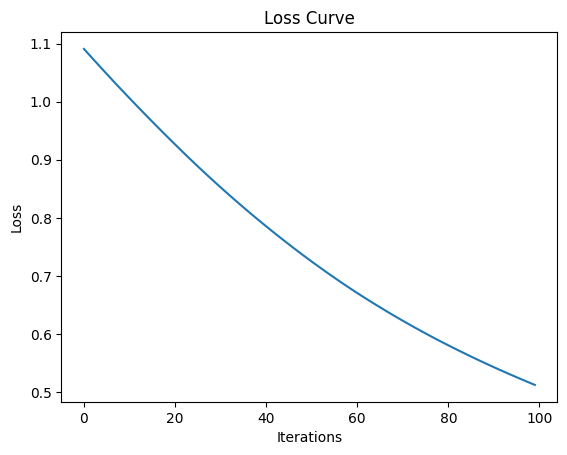

In [39]:
clf = MLPClassifier(hidden_layer_sizes=(16,),alpha=0.1, max_iter=100, random_state=42, verbose=False) 
clf.fit(X_train_std, y_train)

#Visualization of loss curve
plt.plot(clf.loss_curve_)
plt.title("Loss Curve")
plt.xlabel("Iterations")
plt.ylabel("Loss")
plt.show()


In [40]:
y_pred = clf.predict(X_test_std)
print("Test Accuracy Score :" , accuracy_score(y_test, y_pred)) 

Test Accuracy Score : 0.8


In [43]:
X_test_std[1,:]

array([ 0.26392752, -0.34116698,  0.51547131,  0.25106784])

In [44]:
clf.predict_proba(X_test_std[1,:].reshape(1,-1))

array([[0.1929985 , 0.37631594, 0.43068556]])

In [45]:
y_pred[1]

2

Systematic way of model fitting.

Tracking and Training the validation loss per Epoch Manually.

In [46]:
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.4, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

In [47]:
scaler = StandardScaler()
X_train_std = scaler.fit_transform(X_train)
X_test_std = scaler.transform(X_test)
X_val_std = scaler.transform(X_val)

Best Validation Loss: 0.0824 at epoch 614


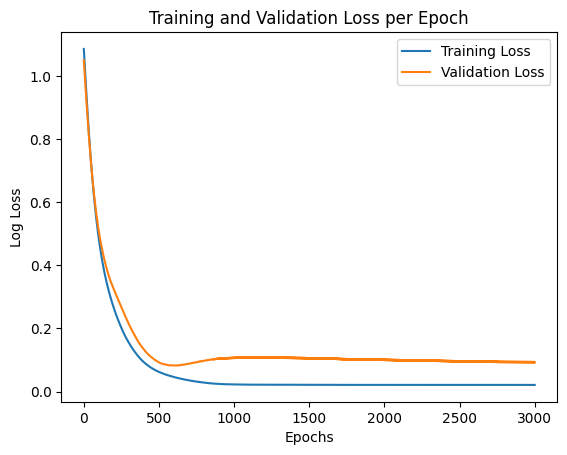

In [56]:
from sklearn.metrics import log_loss

clf = MLPClassifier(hidden_layer_sizes=(16,),alpha=0.1, max_iter=1, warm_start=True, random_state=42)

epochs = 3000
train_losses = []
val_losses = []
best_val_loss = float('inf')
best_epoch = -1
best_model = None   

for epoch in range(epochs):
    clf.fit(X_train_std, y_train)

    #Predict probabilities for log loss calculation
    # train_loss = (log_loss(y_train, train_proba))
    # val_loss = (log_loss(y_val, val_proba))

    y_train_prob = clf.predict_proba(X_train_std)
    y_val_prob = clf.predict_proba(X_val_std)

    train_loss = log_loss(y_train, y_train_prob)
    val_loss = log_loss(y_val, y_val_prob)
    train_losses.append(train_loss)
    val_losses.append(val_loss)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_epoch = epoch + 1
        best_model = copy.deepcopy(clf)

print(f"Best Validation Loss: {best_val_loss:.4f} at epoch {best_epoch}")

plt.plot(range(1, epochs + 1), train_losses, label='Training Loss')
plt.plot(range(1, epochs + 1), val_losses, label='Validation Loss')
# plt.axvline(best_epoch, color='r', linestyle='--', label='Best Epoch')
plt.title("Training and Validation Loss per Epoch")
plt.xlabel("Epochs")
plt.ylabel("Log Loss")
plt.legend()
plt.show()

Comparision of different activation function.

Activation: logistic, Test Accuracy: 0.9000
Activation: tanh, Test Accuracy: 0.9333
Activation: relu, Test Accuracy: 0.9000


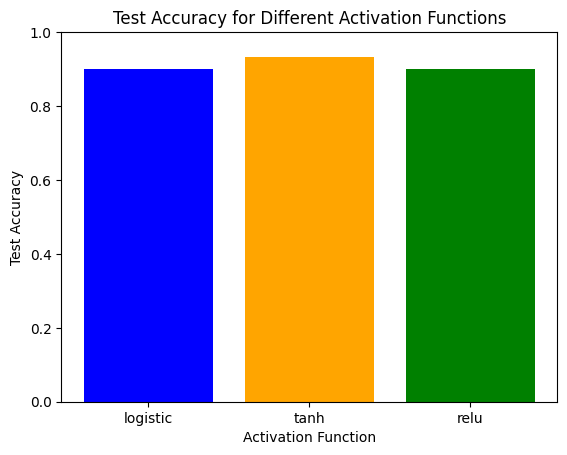

In [58]:
activation_functions = ['logistic', 'tanh', 'relu']
test_accuracies = []

for act in activation_functions:
    clf = MLPClassifier(hidden_layer_sizes=(8,), alpha=0.1, max_iter=1000, random_state=42, activation=act)
    clf.fit(X_train_std, y_train)
    y_pred = clf.predict(X_test_std)
    acc = accuracy_score(y_test, y_pred)
    test_accuracies.append(acc)
    print(f"Activation: {act}, Test Accuracy: {acc:.4f}")

plt.bar(activation_functions, test_accuracies, color=['blue', 'orange', 'green'])

plt.title("Test Accuracy for Different Activation Functions")
plt.xlabel("Activation Function")
plt.ylabel("Test Accuracy")
plt.ylim(0, 1)
plt.show()



Relu is usually best for hidden layer.

Vanishing Gradient Problem in Deep Neural Network.

In [59]:
mlp_vgd = MLPClassifier(hidden_layer_sizes=(16, 16, 16, 16, 16, 16),activation="logistic" , max_iter=100,learning_rate_init=0.01, random_state=42, verbose = True)
history = mlp_vgd.fit(X_train_std, y_train)

# y_pred_vgd = mlp_vgd.predict(X_test_std)
# acc_vgd = accuracy_score(y_test, y_pred_vgd)
# print(f"SGD Solver Test Accuracy: {acc_vgd:.4f}")

Iteration 1, loss = 1.11446933
Iteration 2, loss = 1.10026282
Iteration 3, loss = 1.09970498
Iteration 4, loss = 1.10403045
Iteration 5, loss = 1.10495887
Iteration 6, loss = 1.10273790
Iteration 7, loss = 1.10003682
Iteration 8, loss = 1.09867527
Iteration 9, loss = 1.09903149
Iteration 10, loss = 1.10025685
Iteration 11, loss = 1.10114509
Iteration 12, loss = 1.10107941
Iteration 13, loss = 1.10025065
Iteration 14, loss = 1.09926178
Iteration 15, loss = 1.09866032
Iteration 16, loss = 1.09865547
Iteration 17, loss = 1.09907217
Iteration 18, loss = 1.09952352
Iteration 19, loss = 1.09968181
Training loss did not improve more than tol=0.000100 for 10 consecutive epochs. Stopping.


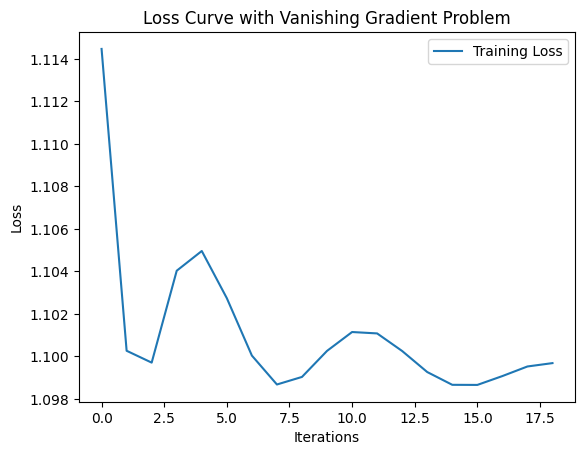

In [60]:
plt.plot(mlp_vgd.loss_curve_, label='Training Loss')
plt.title("Loss Curve with Vanishing Gradient Problem")
plt.xlabel("Iterations")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [65]:
print("Train accuracy:", mlp_vgd.score(X_train, y_train))
print("Test accuracy:", mlp_vgd.score(X_test, y_test))

Train accuracy: 0.3333333333333333
Test accuracy: 0.3333333333333333


Train Test accuracy is same and is very low.

Small Network vs Large Network

In [66]:
mlp_small = MLPClassifier(hidden_layer_sizes=(4,), activation='relu', max_iter=200, random_state=42, early_stopping=False)
mlp_med = MLPClassifier(hidden_layer_sizes=(128,), activation='relu', max_iter=200, random_state=42, early_stopping=False) 
mlp_large = MLPClassifier(hidden_layer_sizes=(512,), activation='relu', max_iter=200, random_state=42, early_stopping=False)   

mlp_small.fit(X_train_std, y_train)
mlp_med.fit(X_train_std, y_train)
mlp_large.fit(X_train_std, y_train)

train_acc_small = mlp_small.score(X_train_std, y_train)
test_acc_small = mlp_small.score(X_test_std, y_test)

train_acc_med = mlp_med.score(X_train_std, y_train)
test_acc_med = mlp_med.score(X_test_std, y_test)    

train_acc_large = mlp_large.score(X_train_std, y_train)
test_acc_large = mlp_large.score(X_test_std, y_test)

In [67]:
print("Small Network - Train Accuracy: {:.4f}, Test Accuracy: {:.4f}".format(train_acc_small, test_acc_small))
print("Medium Network - Train Accuracy: {:.4f}, Test Accuracy: {:.4f}".format(train_acc_med, test_acc_med))
print("Large Network - Train Accuracy: {:.4f}, Test Accuracy: {:.4f}".format(train_acc_large, test_acc_large))

Small Network - Train Accuracy: 0.3444, Test Accuracy: 0.4000
Medium Network - Train Accuracy: 0.9667, Test Accuracy: 0.9333
Large Network - Train Accuracy: 0.9889, Test Accuracy: 0.9333


Hyper parameter training

In [69]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'hidden_layer_sizes': [(8,), (16,), (32,), (64,)],
    'alpha': [0.0001, 0.001, 0.01, 0.1],
    'learning_rate_init': [0.001, 0.01, 0.1],
    'activation': ['logistic', 'tanh', 'relu']
}
grid_search = GridSearchCV(MLPClassifier(max_iter=600, random_state=42), param_grid, cv=3, scoring='accuracy', n_jobs=-1)
grid_search.fit(X_train_std, y_train)

print("Best Hyperparameters:", grid_search.best_params_)
print("Best Cross-Validation Score: {:.4f}".format(grid_search.best_score_))

/opt/anaconda3/pyspark_env/lib/python3.9/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (600) reached and the optimization hasn't converged yet.
  warnings.warn(
/opt/anaconda3/pyspark_env/lib/python3.9/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (600) reached and the optimization hasn't converged yet.
  warnings.warn(
/opt/anaconda3/pyspark_env/lib/python3.9/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (600) reached and the optimization hasn't converged yet.
  warnings.warn(
/opt/anaconda3/pyspark_env/lib/python3.9/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (600) reached and the optimization hasn't converged yet.
  warnings.warn(
/opt/anaconda3/pyspark_e

Best Hyperparameters: {'activation': 'logistic', 'alpha': 0.0001, 'hidden_layer_sizes': (64,), 'learning_rate_init': 0.001}
Best Cross-Validation Score: 1.0000


Predict with best parameter

In [70]:
best_mlp = grid_search.best_estimator_
y_test_pred = best_mlp.predict(X_test_std)

Test Accuracy with Best Hyperparameters: 0.9333
Confusion Matrix:               precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       0.83      1.00      0.91        10
           2       1.00      0.80      0.89        10

    accuracy                           0.93        30
   macro avg       0.94      0.93      0.93        30
weighted avg       0.94      0.93      0.93        30



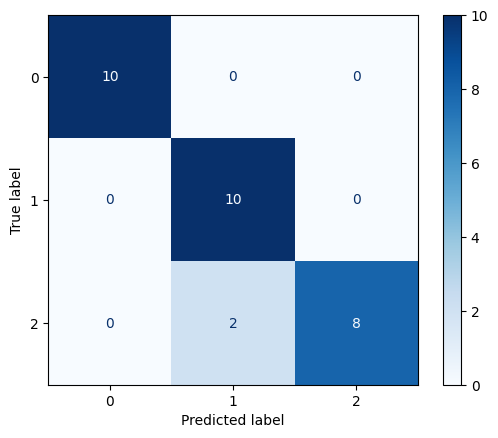

In [72]:
test_acc = accuracy_score(y_test, y_test_pred)
print("Test Accuracy with Best Hyperparameters: {:.4f}".format(test_acc))

print("Confusion Matrix:", classification_report(y_test, y_test_pred))

disp = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix(y_test, y_test_pred))
disp.plot(cmap=plt.cm.Blues)
plt.show()

In [74]:
#Access coefficients and intercepts
weights = best_mlp.coefs_
biases = best_mlp.intercepts_
total_parameters = sum(w.size for w in weights) + sum(b.size for b in biases)
print(f"Total number of parameters in the network: {total_parameters}")
print("Coefficients:", best_mlp.coefs_)
print("Intercepts:", best_mlp.intercepts_)

Total number of parameters in the network: 515
Coefficients: [array([[ 0.20272008,  0.40052929, -0.05333914,  0.13434868, -0.1324016 ,
         0.08047106, -0.66527205, -0.10611135,  0.31862337,  0.25462944,
        -0.04582384,  0.25523545,  0.29389801, -0.29563191,  0.02336533,
         0.1336866 , -0.29475879,  0.10158941,  0.16208383,  0.24676751,
         0.27472911, -0.3316128 ,  0.02349849, -0.16659247, -0.07434145,
        -0.06958128, -0.21275974, -0.33122225,  0.35402389,  0.20416464,
         0.23922462, -0.29534782, -0.15144157,  0.35608154,  0.52583906,
         0.26076085, -0.26058696, -0.32243832,  0.46233391, -0.18575904,
         0.16190026,  0.22085892, -0.33052511,  0.36023097, -0.10485257,
        -0.19369887,  0.16949222, -0.11513934, -0.20657438, -0.59242404,
         0.5404218 , -0.24098226,  0.32870242,  0.40402355,  0.24134179,
        -0.05685038, -0.34795108, -0.33210861, -0.54914194,  0.16448521,
        -0.21225033, -0.24140143, -0.144925  , -0.28172816],
 

Image Classification using Neural Network - MNIST Dataset.

In [77]:
from sklearn.datasets import fetch_openml

In [79]:
X, y = fetch_openml('mnist_784', version=1, return_X_y=True, as_frame=False)
X = X / 255.0  # Normalize pixel values to [0, 1]  

In [ ]:
print("Dataset shape:", X.shape)

Dataset shape: (70000, 784)


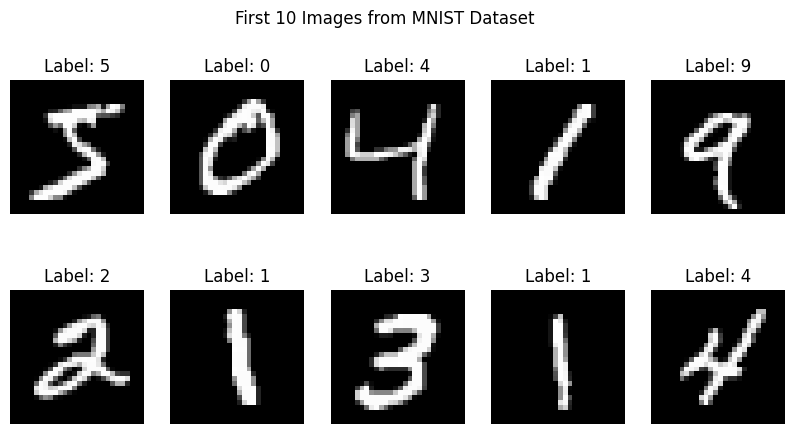

In [ ]:
#Show first 10 images
fig, axes = plt.subplots(2, 5, figsize=(10, 5))
for i, ax in enumerate(axes.flat):
    ax.imshow(X[i].reshape(28, 28), cmap='gray')
    ax.set_title(f"Label: {y[i]}")
    ax.axis('off')
plt.suptitle("First 10 Images from MNIST Dataset")
plt.show()

In [82]:
X_train , X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [83]:
mlp= MLPClassifier(hidden_layer_sizes=(64, 32), activation='relu',solver = 'adam' ,learning_rate_init=0.01, max_iter=3000, random_state=42, verbose=False, validation_fraction=0.1)

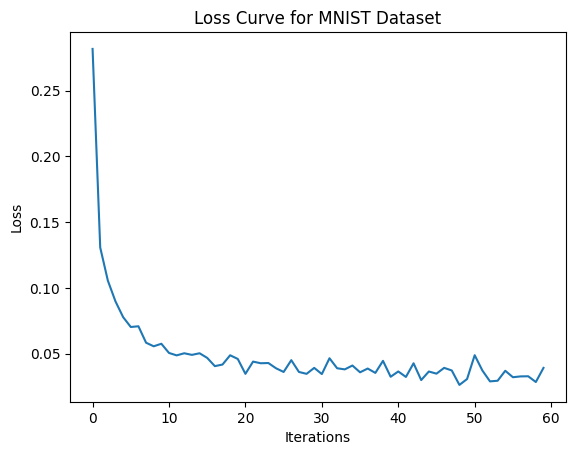

In [84]:
mlp.fit(X_train, y_train)

plt.plot(mlp.loss_curve_)
plt.title("Loss Curve for MNIST Dataset")
plt.xlabel("Iterations")
plt.ylabel("Loss")
plt.show()

Visualise receptive fields of hidden neuron

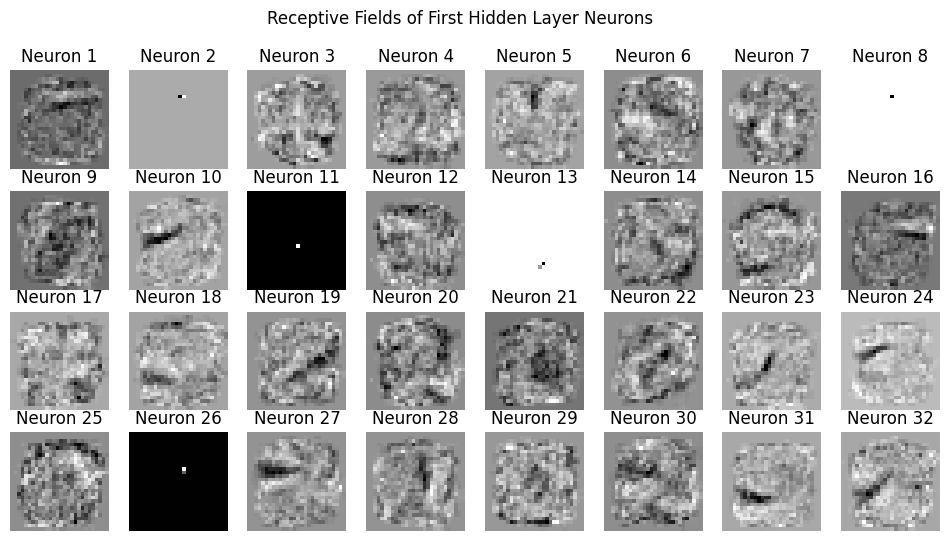

In [87]:
fig, axes = plt.subplots(4, 8, figsize=(12, 6))
#Visualise receptive fields of hidden neuron
for i, ax in enumerate(axes.flat):
    if i < mlp.coefs_[0].shape[1]:  # Number of neurons in the first hidden layer
        weight_image = mlp.coefs_[0][:, i].reshape(28, 28)
        ax.imshow(weight_image, cmap='gray')
        ax.set_title(f"Neuron {i+1}")
    ax.axis('off')
plt.suptitle("Receptive Fields of First Hidden Layer Neurons")
plt.show()


MNIST Test Accuracy: 0.9699


<Figure size 1000x800 with 0 Axes>

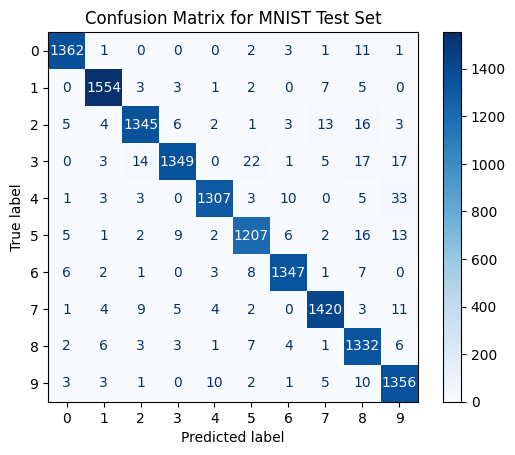

In [88]:
y_pred = mlp.predict(X_test)

acc = accuracy_score(y_test, y_pred)
print(f"MNIST Test Accuracy: {acc:.4f}")

plt.figure(figsize=(10, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix(y_test, y_pred))
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix for MNIST Test Set")
plt.show()